In [1]:
# 02_eda_featurization.ipynb
# Purpose: Explore the processed concrete dataset and create analysis-ready features.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
data_file = Path("../data/concrete_processed.csv")

df = pd.read_csv(data_file)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1030, 11)


,cement,slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,compressive_strength,w_c_ratio,log_age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111,0.300000,3.332205
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366,0.300000,3.332205
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535,0.685714,5.598422
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780,0.685714,5.899897
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075,0.966767,5.886104


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cement,1030.0,281.165631,104.507142,102.000000,192.375000,272.900000,350.000000,540.000000
slag,1030.0,73.895485,86.279104,0.000000,0.000000,22.000000,142.950000,359.400000
fly_ash,1030.0,54.187136,63.996469,0.000000,0.000000,0.000000,118.270000,200.100000
water,1030.0,181.566359,21.355567,121.750000,164.900000,185.000000,192.000000,247.000000
superplasticizer,1030.0,6.203112,5.973492,0.000000,0.000000,6.350000,10.160000,32.200000
coarse_aggregate,1030.0,972.918592,77.753818,801.000000,932.000000,968.000000,1029.400000,1145.000000
fine_aggregate,1030.0,773.578883,80.175427,594.000000,730.950000,779.510000,824.000000,992.600000
age,1030.0,45.662136,63.169912,1.000000,7.000000,28.000000,56.000000,365.000000
compressive_strength,1030.0,35.817836,16.705679,2.331808,23.707115,34.442774,46.136287,82.599225
w_c_ratio,1030.0,0.748269,0.314005,0.266893,0.533333,0.675349,0.935014,1.882353


In [4]:
df["w_c_ratio_bin"] = pd.qcut(
    df["w_c_ratio"],
    q=10,
    labels=False,
    duplicates="drop"
)

df[["w_c_ratio", "w_c_ratio_bin"]].head()

,w_c_ratio,w_c_ratio_bin
0,0.300000,0
1,0.300000,0
2,0.685714,5
3,0.685714,5
4,0.966767,7


In [5]:
featurized_file = "../data/concrete_featurized.csv"

df.to_csv(featurized_file, index=False)

print("Saved:", featurized_file)

Saved: ../data/concrete_featurized.csv


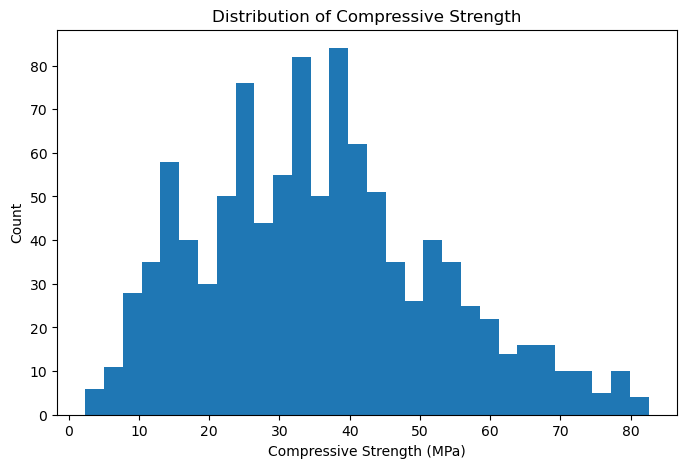

In [6]:
plt.figure(figsize=(8,5))
plt.hist(df["compressive_strength"], bins=30)
plt.xlabel("Compressive Strength (MPa)")
plt.ylabel("Count")
plt.title("Distribution of Compressive Strength")
plt.savefig("../figures/rf_feature_importance.png", dpi=300, bbox_inches="tight")
plt.savefig("../figures/model_comparison.png", dpi=300)
plt.show()

### Compressive Strength Distribution

*The compressive strength distribution is approximately bell-shaped with a slight right skew. Most observations fall between 20 and 50 MPa, while very high-strength concretes above 70 MPa are less common. This suggests that compressive strength is a suitable continuous target variable for regression modeling.*

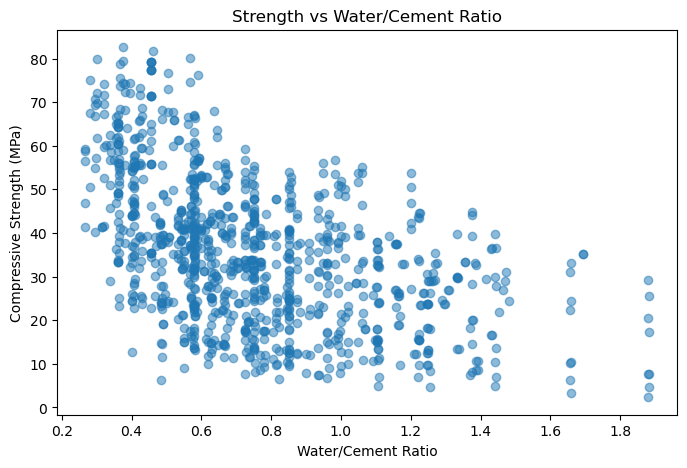

In [7]:
plt.figure(figsize=(8,5))
plt.scatter(df["w_c_ratio"], df["compressive_strength"], alpha=0.5)
plt.xlabel("Water/Cement Ratio")
plt.ylabel("Compressive Strength (MPa)")
plt.title("Strength vs Water/Cement Ratio")
plt.savefig("../figures/rf_feature_importance.png", dpi=300, bbox_inches="tight")
plt.savefig("../figures/model_comparison.png", dpi=300)
plt.show()

### Feature Engineering Evaluation

*The strength versus water-to-cement ratio plot shows a clear negative trend, confirming that the engineered w_c_ratio feature captures an important physical relationship. The strength versus age plot shows that strength generally increases with curing time, although the relationship is nonlinear. This supports the creation of the log_age feature, which exhibited a stronger correlation with strength than raw age.*

In [8]:
corr = df.corr(numeric_only=True)

corr["compressive_strength"].sort_values(ascending=False)

compressive_strength    1.000000
log_age                 0.552185
cement                  0.497833
superplasticizer        0.366102
age                     0.328877
slag                    0.134824
fly_ash                -0.105753
coarse_aggregate       -0.164928
fine_aggregate         -0.167249
water                  -0.289613
w_c_ratio              -0.500700
w_c_ratio_bin          -0.544595
Name: compressive_strength, dtype: float64

### Correlation Analysis

*The strongest positive correlations with compressive strength are log_age (0.552), cement content (0.498), and superplasticizer dosage (0.366). The strongest negative correlations are water-to-cement ratio (-0.501) and water content (-0.290). These relationships are physically reasonable because cement hydration increases strength with curing time, while excess water increases porosity and reduces strength.*

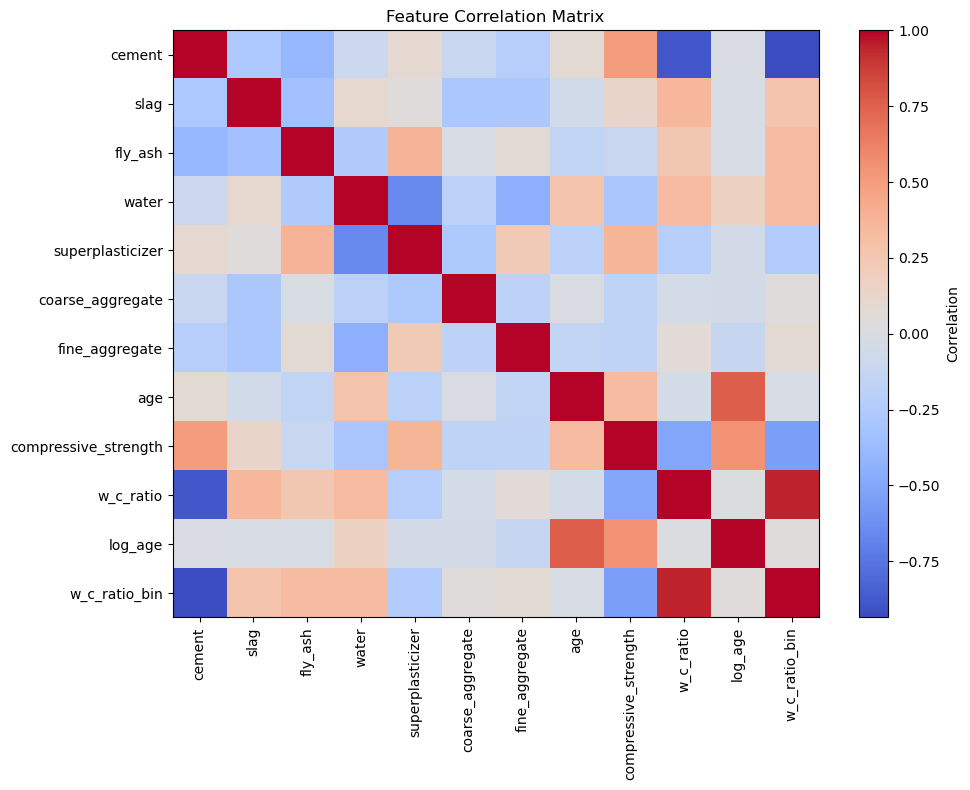

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("../figures/rf_feature_importance.png", dpi=300, bbox_inches="tight")
plt.savefig("../figures/model_comparison.png", dpi=300)
plt.show()

### Correlation Heatmap Interpretation

The correlation matrix highlights relationships among the input variables and the target property. The strongest positive correlations with compressive strength are observed for `log_age`, `cement`, and `superplasticizer`, while `w_c_ratio` exhibits one of the strongest negative correlations. These trends are consistent with established concrete hydration and mix design principles.

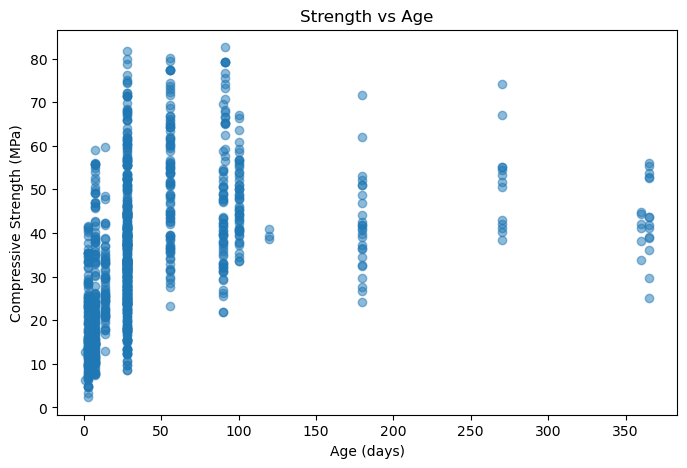

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(df["age"], df["compressive_strength"], alpha=0.5)

plt.xlabel("Age (days)")
plt.ylabel("Compressive Strength (MPa)")
plt.title("Strength vs Age")
plt.savefig("../figures/rf_feature_importance.png", dpi=300, bbox_inches="tight")
plt.savefig("../figures/model_comparison.png", dpi=300)
plt.show()

### Age vs Strength

The strength-versus-age plot shows that compressive strength generally increases with curing time. The relationship is nonlinear, with rapid strength gains occurring at early ages and slower gains at later ages. This behavior explains why the engineered `log_age` feature exhibits a stronger correlation with compressive strength than raw age.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cement                1030 non-null   float64
 1   slag                  1030 non-null   float64
 2   fly_ash               1030 non-null   float64
 3   water                 1030 non-null   float64
 4   superplasticizer      1030 non-null   float64
 5   coarse_aggregate      1030 non-null   float64
 6   fine_aggregate        1030 non-null   float64
 7   age                   1030 non-null   int64  
 8   compressive_strength  1030 non-null   float64
 9   w_c_ratio             1030 non-null   float64
 10  log_age               1030 non-null   float64
 11  w_c_ratio_bin         1030 non-null   int64  
dtypes: float64(10), int64(2)
memory usage: 96.7 KB


## EDA Summary

*The dataset contains 1,030 concrete mixtures with no missing values. Two engineered features were added: water-to-cement ratio (w_c_ratio) and logarithmic curing age (log_age). Exploratory analysis confirmed expected physical relationships between composition, curing time, and compressive strength. The resulting featurized dataset was saved as concrete_featurized.csv for model development.*